## P(X) integration test


In this notebook we will integrate the density probability function $P(\widetilde{X})$ using two approach: 

1. Integrate in a hypervolume of 6 variables 

2. Integrate the positions ($x$,$y$,$z$) in a sphere and the velocities ($v_x$,$v_y$,$v_z$) in a cube

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    trasformation_E_to_X, 
    computeNumericalJacobian,
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

### Veryfing CMND fit 

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


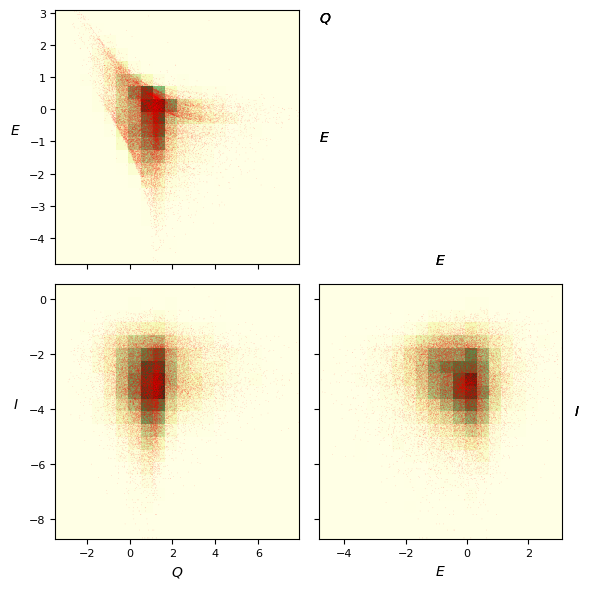

In [3]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [6]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        print('evaluating state vector: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        print('Orbital elements ', q, e, i, Omega, w, M, a)
        if q > 1.35 or e > 1: 
            print("--------------NO SENSE ORBIT-----------------")
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    print("------------PROBLEMATIC POINT------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('--------------Nan value encounter-----------')
                        print(P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    
    return P.reshape(shape), neas_number, not_neas_number

### Integration in hypercube 

In [7]:
def hypercube_surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf, neas_number, not_neas_number = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral, neas_number, not_neas_number

In [9]:
q_max, e_max, i_max =  (1.35, 1.0, np.pi)
x, y, z, vx, vy, vz = (1.0466234757101576, 0.5466234757101576, 0.466234757101576, 0.49175300704240293, 6.775775737844404, 0.49175300704240293)
elements  = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)

q = elements[0]
e = elements[1]
i = elements[2]
Omega = elements[3]
w = elements[4]
M = elements[5]
a = q/(1-e)
print('------------- orbital elements: ------------')
print(q, e, i, Omega, w, M, a)

print('------------- Jacobians: ------------')
J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i, q_max,e_max,i_max)
print('Jacobian coordinate trasformation: ')
print(J)
print('Jaccobian bounded trasformation: ')
print(J_qei_to_QEI)

print('------------- Determinantes: ------------')
det = np.linalg.det(J)
inv_det = 1.0/det 
det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
print('inverse determinant Jacobian coordinate trasformation: ', abs(det))
print('determinant Jaccobian bounded trasformation: ', abs(det_QEI))

print('Probability Calculation')
P = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
print('P = ', P)

------------- orbital elements: ------------
0.8363132560107014 0.6650051644067845 0.4024453927778762 4.810816748402446 0.5010826451283568 0.29113221609418904 2.4964959669594347
------------- Jacobians: ------------
Jacobian coordinate trasformation: 
[[  1.25147302   0.88709633  -0.46397813  -0.54662348  -0.5208964
    0.30867793]
 [  0.65361092   5.7327375   -0.04581638   1.04662348   1.1447306
    4.25321737]
 [  0.55748818   0.61559639   1.09527381   0.          -0.17277609
    0.30867793]
 [ -0.29400049 -12.451743    -0.48937287  -6.77577574  -6.25335869
  -12.68065116]
 [ -4.05097952  -7.59507398  -0.04832404   0.49175301   0.64413732
   -6.62276528]
 [ -0.29400049  -5.59249683   1.15522101   0.          -2.62209288
   -5.64879391]]
Jaccobian bounded trasformation: 
[[3.14243591 0.         0.        ]
 [0.         4.48886837 0.        ]
 [0.         0.         2.84988629]]
------------- Determinantes: ------------
inverse determinant Jacobian coordinate trasformation:  152.424709

In [10]:
q_max, e_max, i_max =  (1.35, 1.0, np.pi)
x, y, z, vx, vy, vz = (-1.0466234757101576, 0.5466234757101576, 0.466234757101576, 0.49175300704240293, 6.775775737844404, 0.49175300704240293)
elements  = spy.oscelt([x, y, z, vx, vy, vz], et=0, mu=mu)

q = elements[0]
e = elements[1]
i = elements[2]
Omega = elements[3]
w = elements[4]
M = elements[5]
a = q/(1-e)
print('------------- orbital elements: ------------')
print(q, e, i, Omega, w, M, a)

print('------------- Jacobians: ------------')
J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i, q_max,e_max,i_max)
print('Jacobian coordinate trasformation: ')
print(J)
print('Jaccobian bounded trasformation: ')
print(J_qei_to_QEI)

print('------------- Determinantes: ------------')
det = np.linalg.det(J)
inv_det = 1.0/det 
det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
print('inverse determinant Jacobian coordinate trasformation: ', abs(det))
print('determinant Jaccobian bounded trasformation: ', abs(det_QEI))

print('Probability Calculation')
P = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
print('P = ', P)

------------- orbital elements: ------------
0.9983947434469251 0.6000815716666655 2.756373762537863 4.460461147764972 0.6582486178415297 0.2667684107272321 2.4964959669594347
------------- Jacobians: ------------
Jacobian coordinate trasformation: 
[[-1.04830628  0.02185976 -0.45151744 -0.54662348  0.55023551  0.30867793]
 [ 0.54750236  4.53391906  0.11621899 -1.04662348  1.13958603  4.25321737]
 [ 0.46698439  0.44967655 -1.14984301  0.         -0.10088281  0.30867793]
 [-0.24627183 10.13140193 -0.47623017 -6.77577574  6.32528206 12.68065116]
 [-3.39333504 -5.08251345  0.12257996  0.49175301 -0.27676628 -6.62276528]
 [-0.24627183 -4.4920821  -1.21277693  0.         -2.51176953 -5.64879391]]
Jaccobian bounded trasformation: 
[[3.84570639 0.         0.        ]
 [0.         4.16695004 0.        ]
 [0.         0.         2.95872219]]
------------- Determinantes: ------------
inverse determinant Jacobian coordinate trasformation:  110.53515059948364
determinant Jaccobian bounded trasforma

### Integrating in the XY - Plane grid mapping in a cube in ($x$,$y$,$z$) and in a sphere in ($v_x$, $v_y$, $v_z$)

In [8]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND
)
from tqdm import tqdm
import numpy as np

In [9]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        if q > 1.35 or e > 1: 
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('Nan value encounter: ', P_E_CMND(a, e, i, F), abs(inv_det), abs(det_QEI))
                        print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    
    return P.reshape(shape)

In [10]:
def sphere_surface_integral_P_X_CMND(
    r: np.array,
    dr: np.array,
    c_v: np.array,
    r_v: float,
    deg: int,
    q_max: int, 
    e_max: int, 
    i_max: int,
    mu=1, 
    F=mm.FitCMND
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    from numpy.polynomial.legendre import leggauss
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    x_vals = r[0] + dr[0] * nodes
    y_vals = r[1] + dr[1] * nodes
    z_vals = r[2] + dr[2] * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r_v / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, X, Y, Z = np.meshgrid(
        rho_vals, theta_vals, phi_vals, x_vals, y_vals, z_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_x, W_y, W_z = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    VX = c_v[0] + Rho * sin_theta * cos_phi
    VY = c_v[1] + Rho * sin_theta * sin_phi
    VZ = c_v[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r_v / 2.0) * (np.pi / 2.0) * np.pi * (dr[0] * dr[1] * dr[2])
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_x * W_y * W_z 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND(X, Y, Z, VX, VY, VZ, q_max, e_max, i_max, mu, F=F)
        
    P_grid = P_output.reshape(total_weights.shape)
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.sum(weighted_values)
    
    return integral_result

In [9]:
x_min, x_max = -0.2, 0.2
y_min, y_max = -1.5, -0.4

z_center = 0.0
dx_cell, dy_cell = 0.1, 0.1
dz = 0.1   

vx_center = 0.01
vy_center = 0.01
vz_center = 0.01

max_elements = (1.35, 1.0, np.pi) 

x_steps = int((x_max - x_min) / dx_cell) + 1
y_steps = int((y_max - y_min) / dy_cell) + 1

x_centers = np.linspace(x_min, x_max, x_steps)
y_centers = np.linspace(y_min, y_max, y_steps)

degree = 6

probability_map = np.zeros((len(y_centers), len(x_centers)))
grid_map = []

print("Starting probability mapping...")
for i, y_c in enumerate(tqdm(y_centers, desc="Y-axis progress")):
    for j, x_c in enumerate(x_centers):  

        a = (x_c**2 + y_c**2)**0.5              
        r_v = (2*mu/a)**0.5

        center_pos = np.array([x_c, y_c, z_center])
        dr = np.array([dx_cell, dy_cell, dz])
        
        center_vel = np.array([vx_center, vy_center, vz_center])
        print(center_pos, dr, center_vel, r_v)
        try:
        # Calculate the integral for this hypervolume
            prob_value = sphere_surface_integral_P_X_CMND(
                center_pos, dr, 
                center_vel, r_v, 
                degree, 
                q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], 
                mu=mu, 
                F=F
            )
            print(prob_value)
        except Exception as err:
            print("Runtime error at center =", center_pos, center_vel)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = prob_value
        grid_map.append(center_pos)
header = f"P(X) XY plane integration cube position and spheric velocity\nmethod: spheric velocities Rv respect to the center\n x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}, dx_cell={dx_cell}, dy_cell={dy_cell}, dz={dz}, vx_center={vx_center}, vy_center={vy_center}, vz_center={vz_center}"

# Save to a .dat file
print("Mapping complete!")
np.savetxt(f"PX_integration_XY_grid_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}2.dat", probability_map, header=header, delimiter=', ')
np.savetxt(f"XY_grid_map_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}2.dat", grid_map, header=header, delimiter=', ')

Starting probability mapping...


Y-axis progress:   0%|          | 0/12 [00:00<?, ?it/s]

[-0.2 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.224268430124559
0.0001850330477216644
[-0.1 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.248124346707702
0.00017594950246672356
[ 0.  -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.256164430444524
0.0001708410409628166
[ 0.1 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.248124346707702
0.00017543539831343824
[ 0.2 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.224268430124559


Y-axis progress:   8%|▊         | 1/12 [04:10<45:50, 250.03s/it]

0.0001858204062415483
[-0.2 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.473004542308567
0.00020198030926205044
[-0.1 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.501294024276993
0.0001999454068585337
[ 0.  -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.510843749562193
0.00019549888391561578
[ 0.1 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.501294024276993
0.0002001872944980208
[ 0.2 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.473004542308567


...

0.00014073760302465833
[-0.2 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.110253820420974
0.00011345621931205215
[-0.1 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.445415720835678
0.00011054008546134177
[ 0.  -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.568045461604001
0.00011008182412941367
[ 0.1 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.445415720835678
0.00011062032615899128
[ 0.2 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.110253820420974


Y-axis progress:  92%|█████████▏| 11/12 [53:31<04:45, 285.29s/it]

0.00011362968972473358
[-0.2 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 13.28909010871467
9.137367730986518e-05
[-0.1 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 13.840141005554768
8.297680335201759e-05
[ 0.  -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 14.051501998227133
8.07668168007188e-05
[ 0.1 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 13.840141005554768
8.30327724304534e-05
[ 0.2 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 13.28909010871467


Y-axis progress: 100%|██████████| 12/12 [58:31<00:00, 292.66s/it]

9.149784918589177e-05
Mapping complete!
